# 03b – N-gram follow-ups
(1) Ney's closed-form discount estimate vs the tuned discount, (2) how much of the keystroke savings comes from word completion alone vs context. Uses the models saved by `03_ngram.ipynb`; only the **validation** split is touched.

In [1]:
import sys, pickle
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import data as D, evaluate as E
vocab = D.load_vocab()
kn3 = pickle.load(open(ROOT / "models" / "kn3.pkl", "rb"))
unigram = pickle.load(open(ROOT / "models" / "unigram.pkl", "rb"))

## 1. Ney's discount estimate
For the highest order the adjusted counts are raw counts, so with n1 / n2 = number of trigram *types* seen exactly once / twice in train, Ney's estimate is **D = n1 / (n1 + 2·n2)**. (For the lower KN levels the same formula applies to the continuation counts; shown for information – the model uses one shared d.)

In [2]:
def ney(vals):
    n1, n2 = int((vals == 1).sum()), int((vals == 2).sum())
    return n1, n2, n1 / (n1 + 2 * n2)

rows = []
for label, vals in [("trigram level (raw counts)", kn3.levels[3].vals),
                    ("bigram level (continuation counts)", kn3.levels[2].vals),
                    ("unigram level (continuation counts)", kn3.a1[kn3.a1 > 0])]:
    n1, n2, d = ney(vals)
    rows.append({"level": label, "n1": n1, "n2": n2, "ney_D": round(d, 4)})
ney_df = pd.DataFrame(rows)
display(ney_df)

D_ney = ney_df.loc[0, "ney_D"]
rows = []
for d in (0.8, D_ney, 0.9):
    kn3.d = d
    rows.append({"d": d, "source": "Ney (trigram count-of-counts)" if d == D_ney else "grid", "val_ppl": E.evaluate(kn3, "val", vocab, metrics="ppl", log=False)["ppl"]})
kn3.d = 0.9                                         # restore the tuned value
cmp_d = pd.DataFrame(rows).round(3)
display(cmp_d)
ney_df.to_csv(ROOT / "tables" / "ngram_ney_discount.csv", index=False)
cmp_d.to_csv(ROOT / "tables" / "ngram_ney_vs_tuned.csv", index=False)

,level,n1,n2,ney_D
0,trigram level (raw counts),486834,41619,0.8540
1,bigram level (continuation counts),171476,31137,0.7336
2,unigram level (continuation counts),570,3707,0.0714


,d,source,val_ppl
0,0.800,grid,139.165
1,0.854,Ney (trigram count-of-counts),137.361
2,0.900,grid,136.666


## 2. Keystroke savings: word completion alone vs context
Four validation runs of the KSR simulation (same targets, same 3 suggestions):
- **unigram, no completion** – the 3 most frequent words shown only before typing anything;
- **unigram + completion** – the same unigram ranking, filtered by the typed prefix (word completion *alone*, no context);
- **KN-3, no completion** – context-aware suggestions only before the first letter;
- **KN-3 + completion** – the full system.

,system,ksr,top3,archaic_ksr
0,"unigram, no completion",0.0429,0.0881,0.0000
1,unigram + completion,0.3967,0.0881,0.3461
2,"KN-3, no completion",0.1260,0.2281,0.1216
3,KN-3 + completion,0.4789,0.2281,0.5064


word completion alone (unigram + prefix filter): KSR = 39.7 %
full system (KN-3 + completion):                 KSR = 47.9 %
=> completion alone gives 83 % of the saving; context adds 8.2 points


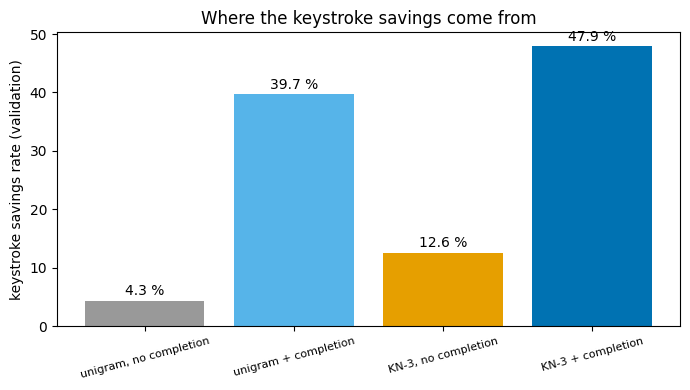

In [3]:
rows = []
for label, model, comp in [("unigram, no completion", unigram, False), ("unigram + completion", unigram, True),
                           ("KN-3, no completion", kn3, False), ("KN-3 + completion", kn3, True)]:
    r = E.evaluate(model, "val", vocab, prefix_completion=comp, log=False)
    rows.append({"system": label, "ksr": r["ksr"], "top3": r["top3"], "archaic_ksr": r["archaic_ksr"]})
ksr = pd.DataFrame(rows)
base = ksr.loc[ksr["system"] == "unigram + completion", "ksr"].iloc[0]
full = ksr.loc[ksr["system"] == "KN-3 + completion", "ksr"].iloc[0]
display(ksr.round(4))
print(f"word completion alone (unigram + prefix filter): KSR = {100 * base:.1f} %")
print(f"full system (KN-3 + completion):                 KSR = {100 * full:.1f} %")
print(f"=> completion alone gives {100 * base / full:.0f} % of the saving; context adds {100 * (full - base):.1f} points")
ksr.round(4).to_csv(ROOT / "tables" / "ngram_ksr_decomposition.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
cols = ["#999999", "#56B4E9", "#E69F00", "#0072B2"]
bars = ax.bar(ksr["system"], 100 * ksr["ksr"], color=cols)
ax.bar_label(bars, labels=[f"{100 * v:.1f} %" for v in ksr["ksr"]], padding=2)
ax.set_ylabel("keystroke savings rate (validation)"); ax.set_title("Where the keystroke savings come from")
ax.tick_params(axis="x", labelsize=8, rotation=15)
plt.tight_layout(); fig.savefig(ROOT / "figures" / "ngram_ksr_decomposition.png", dpi=200, bbox_inches="tight"); plt.show()